# Segmentação de Músicas por Características

Este notebook demonstra dois paradigmas de aprendizado de máquina usando segmentação musical:

| Etapa | Tipo | Algoritmo | Pergunta respondida |
|-------|------|-----------|---------------------|
| 1 | **Não-supervisionado** | K-Means | Quais perfis de música existem? |
| 2 | **Supervisionado** | Decision Tree | Dado uma nova música, qual é seu gênero? |

---

## Modelo PDA

As músicas são descritas por três métricas inspiradas no modelo RFM do marketing:

- **P — Plays:** número de reproduções na plataforma (maior = mais popular)
- **D — Duração:** duração da música em segundos (clássicas são longas; jingles, curtíssimos)
- **A — Ano de lançamento:** quanto mais antigo, maior a chance de ser clássico; jingles políticos concentram-se em anos eleitorais (2002, 2006, 2010, 2014, 2018, 2022)

## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
sns.set_theme(style='whitegrid')
print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Geração do Dataset

Simulamos 300 músicas com perfis distintos:

- **Clássica:** duração longa (5–15 min), lançamento entre 1700–1940, popularidade moderada
- **Pop:** duração média (2,5–4 min), lançamento recente (1985–2024), popularidade muito alta
- **Jingle Político:** duração curtíssima (20–60 s), lançado exclusivamente em anos eleitorais brasileiros, popularidade baixa

In [2]:
n = 100  # músicas por gênero

anos_eleitorais = [2002, 2006, 2010, 2014, 2018, 2022]

# Gênero: Clássica
classica = pd.DataFrame({
    'plays':            np.random.randint(1_000, 50_000, n),
    'duracao_seg':      np.random.randint(300, 900, n),
    'ano_lancamento':   np.random.randint(1700, 1941, n),
})

# Gênero: Pop
pop = pd.DataFrame({
    'plays':            np.random.randint(500_000, 5_000_000, n),
    'duracao_seg':      np.random.randint(150, 241, n),
    'ano_lancamento':   np.random.randint(1985, 2025, n),
})

# Gênero: Jingle Político
jingle = pd.DataFrame({
    'plays':            np.random.randint(5_000, 100_000, n),
    'duracao_seg':      np.random.randint(20, 61, n),
    'ano_lancamento':   np.random.choice(anos_eleitorais, n),
})

df = pd.concat([classica, pop, jingle], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # embaralha

print(f'Dataset: {df.shape[0]} músicas, {df.shape[1]} variáveis')
df.head(10)

Dataset: 300 músicas, 3 variáveis


,plays,duracao_seg,ano_lancamento
0,35355,36,2002
1,87844,36,2006
2,2303649,182,2020
3,48191,789,1900
4,22640,31,2022
5,66642,47,2010
6,1471525,239,2003
7,2731660,212,2020
8,7265,691,1838
9,1149150,182,1986


## 3. Análise Exploratória

In [3]:
df.describe().round(1)

,plays,duracao_seg,ano_lancamento
count,300.0,300.0,300.0
mean,961588.8,282.0,1949.5
std,1521642.6,263.8,91.1
min,1161.0,20.0,1701.0
25%,24793.5,49.0,1874.8
50%,48054.5,192.5,2002.0
75%,1641829.2,484.5,2014.0
max,4979125.0,892.0,2024.0


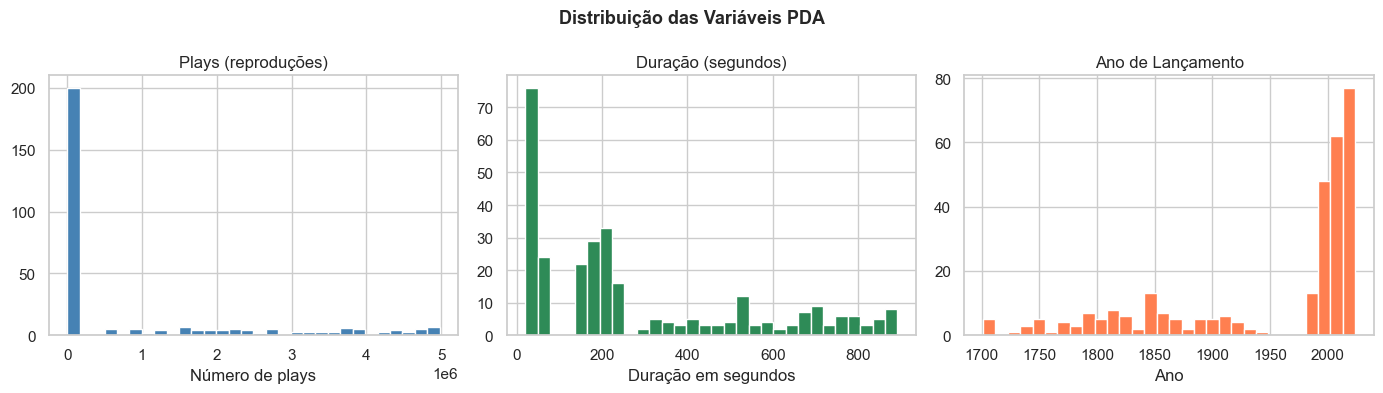

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['plays'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Plays (reproduções)')
axes[0].set_xlabel('Número de plays')

axes[1].hist(df['duracao_seg'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Duração (segundos)')
axes[1].set_xlabel('Duração em segundos')

axes[2].hist(df['ano_lancamento'], bins=30, color='coral', edgecolor='white')
axes[2].set_title('Ano de Lançamento')
axes[2].set_xlabel('Ano')

plt.suptitle('Distribuição das Variáveis PDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Pré-processamento

O K-Means é sensível à escala das variáveis. `plays` varia de milhares a milhões, enquanto `duracao_seg` vai de 20 a 900 e `ano_lancamento` de 1700 a 2024.

Usamos **StandardScaler** para colocar todas as variáveis na mesma escala (média 0, desvio padrão 1).

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print('Antes da normalização:')
print(df.describe().round(1))
print('\nApós a normalização (médias devem ser ~0):')
print(pd.DataFrame(X_scaled, columns=df.columns).describe().round(2))

Antes da normalização:
           plays  duracao_seg  ano_lancamento
count      300.0        300.0           300.0
mean    961588.8        282.0          1949.5
std    1521642.6        263.8            91.1
min       1161.0         20.0          1701.0
25%      24793.5         49.0          1874.8
50%      48054.5        192.5          2002.0
75%    1641829.2        484.5          2014.0
max    4979125.0        892.0          2024.0

Após a normalização (médias devem ser ~0):
        plays  duracao_seg  ano_lancamento
count  300.00       300.00          300.00
mean     0.00         0.00           -0.00
std      1.00         1.00            1.00
min     -0.63        -0.99           -2.73
25%     -0.62        -0.88           -0.82
50%     -0.60        -0.34            0.58
75%      0.45         0.77            0.71
max      2.64         2.32            0.82


---
# PARTE 1 — Aprendizado Não-Supervisionado
## 5. K-Means: Escolha do Número de Clusters

O **Método do Cotovelo (Elbow Method)** testa vários valores de K e mede a inércia (soma das distâncias ao centróide). O "cotovelo" da curva indica o K ideal.

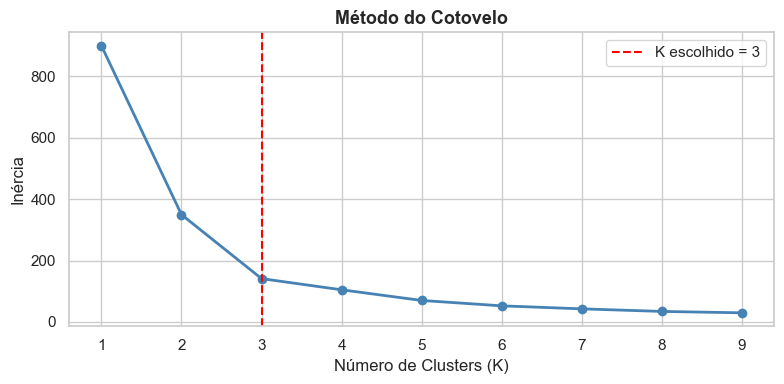

In [6]:
inercias = []
valores_k = range(1, 10)

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(valores_k, inercias, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='K escolhido = 3')
plt.title('Método do Cotovelo', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Aplicando K-Means com K=3

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print('Músicas por cluster:')
print(df['cluster'].value_counts().sort_index())

Músicas por cluster:
cluster
0    100
1    128
2     72
Name: count, dtype: int64


## 7. Interpretando os Clusters

In [8]:
perfil = df.groupby('cluster')[['plays', 'duracao_seg', 'ano_lancamento']].mean().round(1)
perfil['qtd_musicas'] = df['cluster'].value_counts().sort_index()
print(perfil)

# Renomear clusters com base no perfil observado:
#   maior plays         → Pop
#   maior duracao_seg   → Clássica
#   menor ano (restante)→ Clássica; menor duracao → Jingle
medias = df.groupby('cluster')[['plays', 'duracao_seg', 'ano_lancamento']].mean()

cluster_pop     = medias['plays'].idxmax()
cluster_classica = medias['duracao_seg'].idxmax()
cluster_jingle  = [c for c in [0, 1, 2] if c not in [cluster_pop, cluster_classica]][0]

nomes = {
    cluster_pop:      'Pop',
    cluster_classica: 'Clássica',
    cluster_jingle:   'Jingle Político',
}
df['genero'] = df['cluster'].map(nomes)

print('\nRótulos atribuídos:', nomes)

             plays  duracao_seg  ano_lancamento  qtd_musicas
cluster                                                     
0          22713.0        614.3          1831.0          100
1         295281.3         72.7          2011.1          128
2        3450129.8        192.8          2004.5           72

Rótulos atribuídos: {np.int32(2): 'Pop', np.int32(0): 'Clássica', 1: 'Jingle Político'}


## 8. Visualização dos Clusters

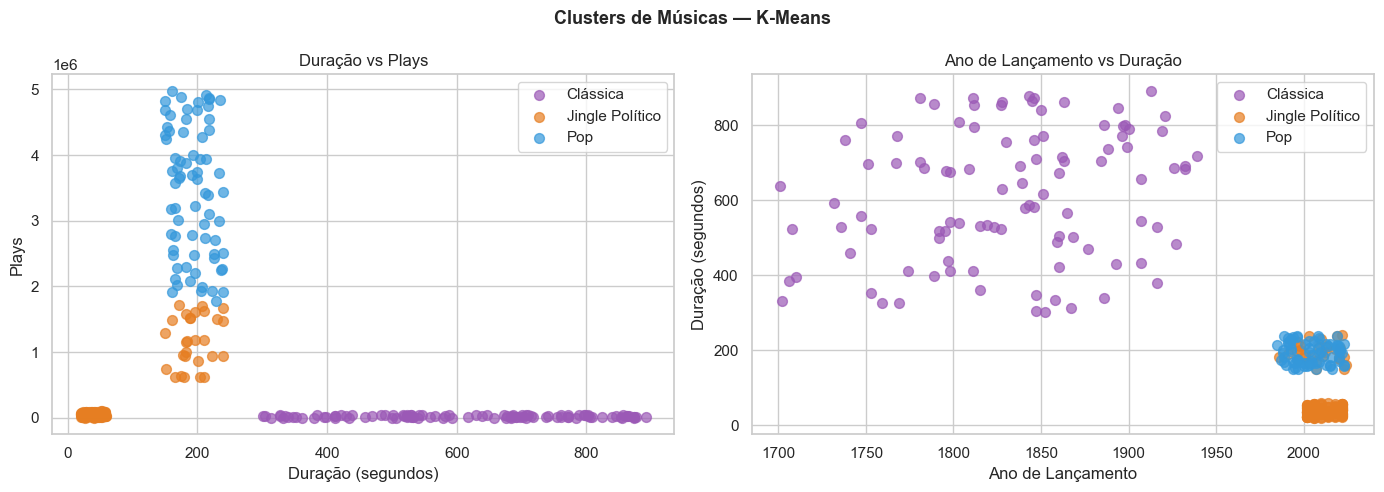

In [9]:
cores = {'Pop': '#3498db', 'Clássica': '#9b59b6', 'Jingle Político': '#e67e22'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Duração vs Plays
for genero_nome, grupo in df.groupby('genero'):
    axes[0].scatter(grupo['duracao_seg'], grupo['plays'],
                    label=genero_nome, color=cores[genero_nome], alpha=0.7, s=50)
axes[0].set_xlabel('Duração (segundos)')
axes[0].set_ylabel('Plays')
axes[0].set_title('Duração vs Plays')
axes[0].legend()

# Gráfico 2: Ano de Lançamento vs Duração
for genero_nome, grupo in df.groupby('genero'):
    axes[1].scatter(grupo['ano_lancamento'], grupo['duracao_seg'],
                    label=genero_nome, color=cores[genero_nome], alpha=0.7, s=50)
axes[1].set_xlabel('Ano de Lançamento')
axes[1].set_ylabel('Duração (segundos)')
axes[1].set_title('Ano de Lançamento vs Duração')
axes[1].legend()

plt.suptitle('Clusters de Músicas — K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

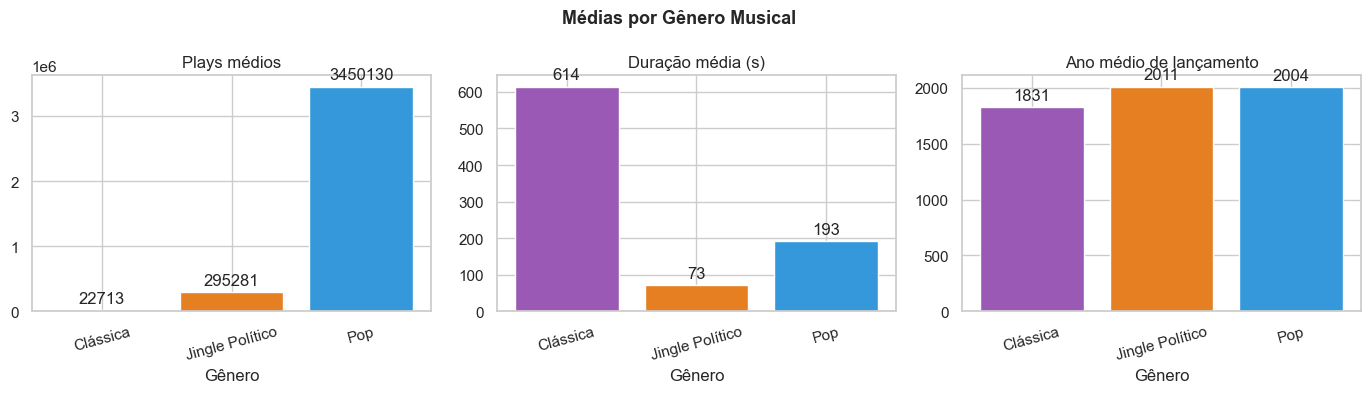

In [10]:
# Médias por gênero — gráfico de barras
resumo = df.groupby('genero')[['plays', 'duracao_seg', 'ano_lancamento']].mean().round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metricas = ['plays', 'duracao_seg', 'ano_lancamento']
titulos  = ['Plays médios', 'Duração média (s)', 'Ano médio de lançamento']
cor_list = [cores[g] for g in resumo.index]

for ax, metrica, titulo in zip(axes, metricas, titulos):
    bars = ax.bar(resumo.index, resumo[metrica], color=cor_list, edgecolor='white')
    ax.bar_label(bars, fmt='%.0f', padding=3)
    ax.set_title(titulo)
    ax.set_xlabel('Gênero')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Médias por Gênero Musical', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PARTE 2 — Aprendizado Supervisionado

Agora que os clusters foram descobertos e rotulados, usamos esses rótulos como **variável alvo** para treinar uma Árvore de Decisão.

> **Cenário:** uma nova música entra no catálogo — sem precisar rodar o K-Means novamente, o classificador identifica o gênero instantaneamente.

## 9. Preparação dos Dados

In [11]:
X = df[['plays', 'duracao_seg', 'ano_lancamento']]
y = df['genero']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Treino: {len(X_train)} músicas')
print(f'Teste:  {len(X_test)} músicas')
print(f'\nDistribuição no treino:\n{y_train.value_counts()}')

Treino: 225 músicas
Teste:  75 músicas

Distribuição no treino:
genero
Jingle Político    96
Clássica           75
Pop                54
Name: count, dtype: int64


## 10. Treinamento da Árvore de Decisão

In [12]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f'Acurácia no conjunto de teste: {acuracia:.2%}')

Acurácia no conjunto de teste: 98.67%


## 11. Matriz de Confusão

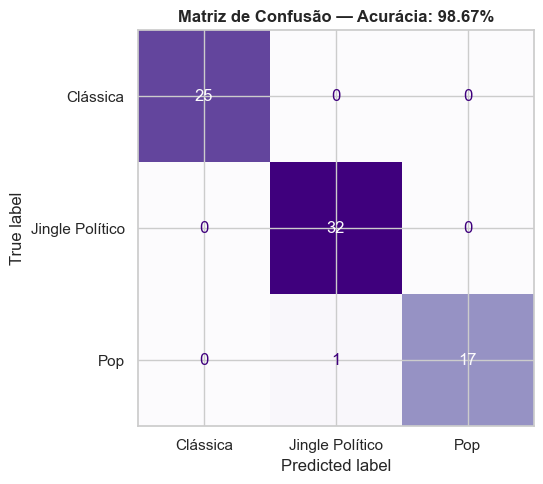


Diagonal = acertos | Fora da diagonal = erros


In [13]:
classes = ['Clássica', 'Jingle Político', 'Pop']
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'Matriz de Confusão — Acurácia: {acuracia:.2%}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDiagonal = acertos | Fora da diagonal = erros')

## 12. Visualização da Árvore de Decisão

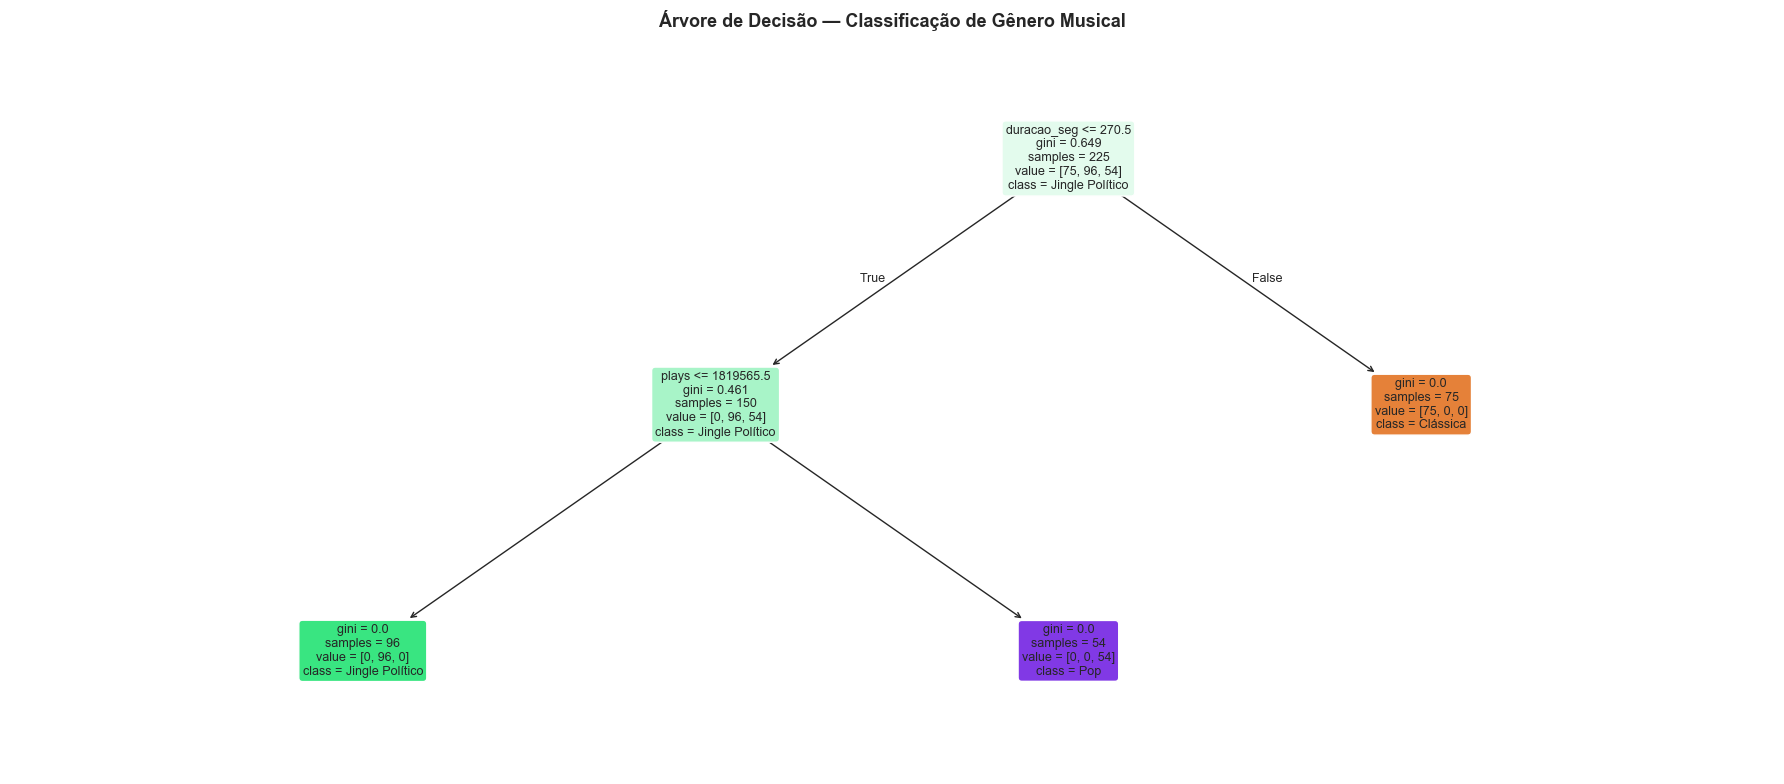

In [14]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=['plays', 'duracao_seg', 'ano_lancamento'],
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Árvore de Decisão — Classificação de Gênero Musical',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Importância das Variáveis

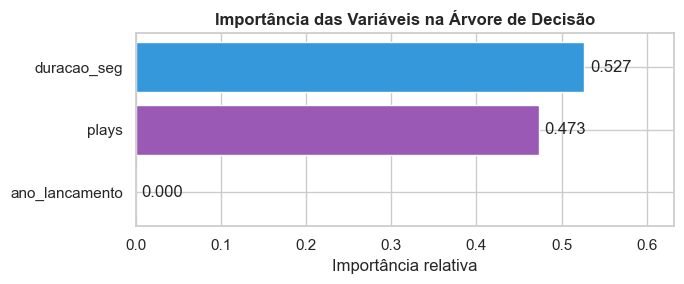

In [15]:
importancias = pd.Series(
    tree.feature_importances_,
    index=['plays', 'duracao_seg', 'ano_lancamento']
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(importancias.index, importancias.values,
               color=['#e67e22', '#9b59b6', '#3498db'], edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4)
ax.set_xlim(0, importancias.max() * 1.2)
ax.set_title('Importância das Variáveis na Árvore de Decisão',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importância relativa')
plt.tight_layout()
plt.show()

## 14. Predição para Novas Músicas

In [16]:
novas_musicas = pd.DataFrame({
    'plays':           [3_200_000,  25_000,  40_000],
    'duracao_seg':     [210,        480,     35],
    'ano_lancamento':  [2019,       1875,    2022],
}, index=['Música A', 'Música B', 'Música C'])

novas_musicas['genero_previsto'] = tree.predict(novas_musicas)

print(novas_musicas)

            plays  duracao_seg  ano_lancamento  genero_previsto
Música A  3200000          210            2019              Pop
Música B    25000          480            1875         Clássica
Música C    40000           35            2022  Jingle Político


---
# PARTE 3 — Rede Neural (MLP)

Uma **Rede Neural Artificial** (do tipo MLP — *Multi-Layer Perceptron*) aprende padrões de forma muito diferente da Árvore de Decisão:

| | Árvore de Decisão | Rede Neural (MLP) |
|---|---|---|
| **Como aprende** | Regras if/else sobre variáveis | Pesos ajustados por backpropagation |
| **Interpretação** | Fácil — cada nó é uma regra | Difícil — "caixa preta" |
| **Expressividade** | Fronteiras ortogonais | Fronteiras curvas e complexas |
| **Dados necessários** | Poucos dados bastam | Beneficia de muitos dados |

### Arquitetura usada



> **Atenção — normalização obrigatória:** ao contrário da Árvore de Decisão, a rede neural é extremamente sensível à escala das variáveis.
>  vai de milhares a milhões enquanto  fica em centenas — sem normalizar, o gradiente fica distorcido e o modelo não aprende.
> Por isso criamos um novo  exclusivo para esta etapa.

## 16. Importação adicional e treinamento da Rede Neural

In [17]:
from sklearn.neural_network import MLPClassifier

# Redes neurais SÃO sensíveis à escala — normalizamos os dados antes de treinar
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train)
X_test_scaled  = scaler_mlp.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 camadas ocultas: 64 e 32 neurônios
    activation='relu',             # função de ativação ReLU
    solver='adam',                 # otimizador Adam (gradiente descendente adaptativo)
    max_iter=500,                  # máximo de épocas de treinamento
    random_state=42,
    verbose=False
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)
acuracia_mlp = accuracy_score(y_test, y_pred_mlp)

print(f'Épocas treinadas:              {mlp.n_iter_}')
print(f'Acurácia — Rede Neural (MLP):  {acuracia_mlp:.2%}')
print(f'Acurácia — Árvore de Decisão:  {acuracia:.2%}')

Épocas treinadas:              289
Acurácia — Rede Neural (MLP):  100.00%
Acurácia — Árvore de Decisão:  98.67%


/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: Runt

## 17. Curva de Perda (Loss) durante o Treinamento

A curva de loss mostra como o erro do modelo diminui a cada época (passagem completa pelos dados de treino). Numa rede saudável ela deve cair suavemente até estabilizar.

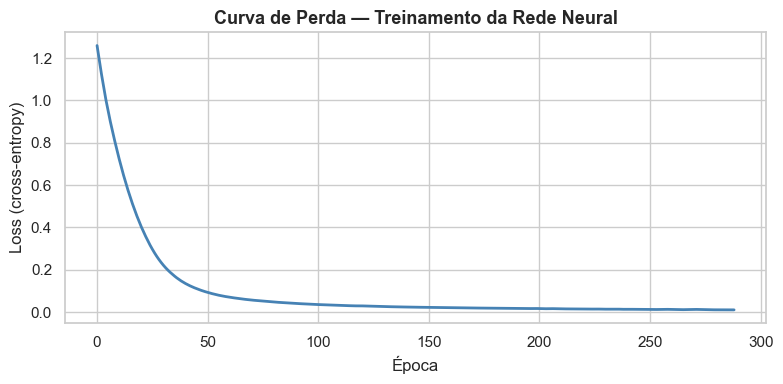

Loss inicial:  1.2589
Loss final:    0.0107


In [18]:
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color='steelblue', linewidth=2)
plt.title('Curva de Perda — Treinamento da Rede Neural', fontsize=13, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss (cross-entropy)')
plt.tight_layout()
plt.show()

print(f'Loss inicial:  {mlp.loss_curve_[0]:.4f}')
print(f'Loss final:    {mlp.loss_curve_[-1]:.4f}')

## 18. Matriz de Confusão — Rede Neural

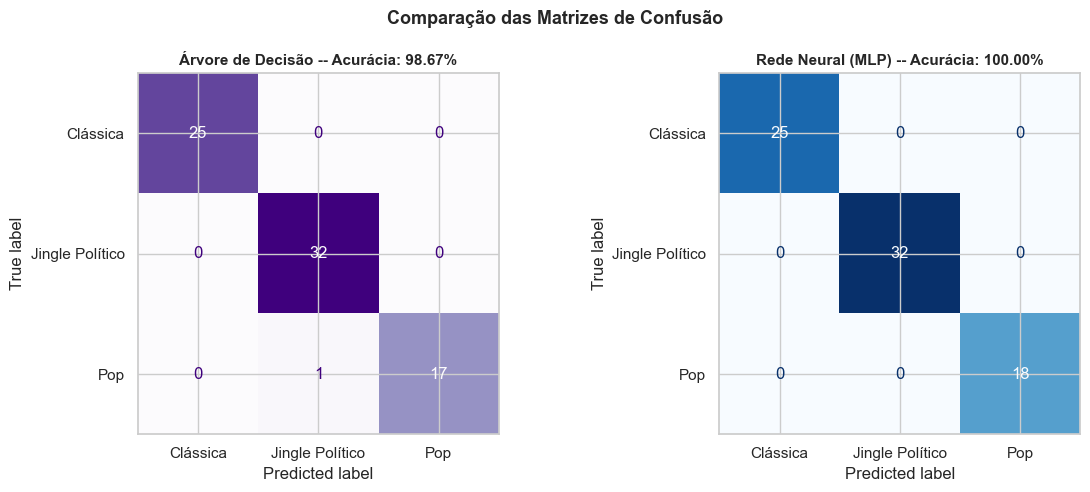

In [19]:
classes = ['Clássica', 'Jingle Político', 'Pop']
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Árvore de Decisão
cm_tree = confusion_matrix(y_test, y_pred, labels=classes)
ConfusionMatrixDisplay(cm_tree, display_labels=classes).plot(
    ax=axes[0], colorbar=False, cmap='Purples')
titulo_tree = f'Árvore de Decisão -- Acurácia: {acuracia:.2%}'
axes[0].set_title(titulo_tree, fontsize=11, fontweight='bold')

# Rede Neural
ConfusionMatrixDisplay(cm_mlp, display_labels=classes).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
titulo_mlp = f'Rede Neural (MLP) -- Acurácia: {acuracia_mlp:.2%}'
axes[1].set_title(titulo_mlp, fontsize=11, fontweight='bold')

plt.suptitle('Comparação das Matrizes de Confusão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 19. Predição para Novas Músicas — comparando os dois modelos

In [20]:
features = ['plays', 'duracao_seg', 'ano_lancamento']

novas = pd.DataFrame({
    'plays':           [3_200_000,  25_000,  40_000],
    'duracao_seg':     [210,        480,     35],
    'ano_lancamento':  [2019,       1875,    2022],
}, index=['Música A', 'Música B', 'Música C'])

# Árvore de Decisão: usa dados brutos
novas['arvore']     = tree.predict(novas[features])

# Rede Neural: precisa dos mesmos dados normalizados usados no treino
novas_scaled = scaler_mlp.transform(novas[features])
novas['rede_neural'] = mlp.predict(novas_scaled)

print(novas)


            plays  duracao_seg  ano_lancamento           arvore  \
Música A  3200000          210            2019              Pop   
Música B    25000          480            1875         Clássica   
Música C    40000           35            2022  Jingle Político   

              rede_neural  
Música A              Pop  
Música B         Clássica  
Música C  Jingle Político  


/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/absence/Projects/UFSC/ia-dec7133-guilherme/supervisionado-naosupervisionado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


---
## 20. Resumo Final — Três Algoritmos

| | K-Means | Árvore de Decisão | Rede Neural (MLP) |
|---|---|---|---|
| **Tipo** | Não-supervisionado | Supervisionado | Supervisionado |
| **Entrada** | Sem rótulo | Com rótulo | Com rótulo |
| **Saída** | Grupos descobertos | Regras if/else | Pesos nas conexões |
| **Interpretável?** | Sim (centróides) | Sim (árvore visual) | Não (caixa preta) |
| **Avaliação** | Inércia / cotovelo | Acurácia, matriz confusão | Acurácia, curva de loss |
| **Ideal quando** | Exploração sem rótulos | Poucos dados, explicabilidade | Muitos dados, padrões complexos |

### Fluxo completo


> **Para dados simples e bem separados como este**, a Árvore de Decisão e a Rede Neural tendem a ter desempenho similar. A vantagem da rede neural aparece quando os padrões são não-lineares e os dados são volumosos.